# Customer Segmentation — KMeans, DBSCAN, and PCA
**Assignment 2 — Unsupervised Learning**

Dataset: [Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis) (Kaggle)

**Goal:** understand how different clustering algorithms behave on real customer
behavioral data — not to assume every discovered cluster is automatically a
"real" business segment. We already cleaned and engineered features in
`data_preparation.py`; this notebook picks up from the prepared data and runs
the actual clustering analysis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/prepared_data.csv")          # unscaled, for profiling
X_scaled = pd.read_csv("../data/prepared_data_scaled.csv")  # scaled, for modeling

features = ["Income", "Recency", "Total_Spend", "Total_Purchases",
            "Age", "Customer_Tenure_Days", "NumWebVisitsMonth", "Family_Size"]

print(df.shape, X_scaled.shape)
df[features].head()


(2212, 30) (2212, 8)


,Income,Recency,Total_Spend,Total_Purchases,Age,Customer_Tenure_Days,NumWebVisitsMonth,Family_Size
0,58138.0,58,1617,25,57,663,7,1
1,46344.0,38,27,6,60,113,5,3
2,71613.0,26,776,21,49,312,4,2
3,26646.0,26,53,8,30,139,6,3
4,58293.0,94,422,19,33,161,5,3


## 1. Why scaling matters

`Income` ranges into the tens of thousands, while `Family_Size` ranges roughly
1–6. Both KMeans and DBSCAN rely on **Euclidean distance** to decide which
points are "close". Left unscaled, Income alone would dominate every distance
calculation and the algorithms would effectively cluster on income only,
ignoring recency, tenure, or purchase behavior entirely. `StandardScaler`
(mean 0, std 1 per feature) puts every feature on comparable footing so each
one contributes proportionally to the notion of similarity.

We already applied `StandardScaler` in `data_preparation.py` — the cell below
just confirms it.

In [2]:
print("Scaled feature means (~0) and stds (~1):")
X_scaled.describe().loc[["mean", "std"]].round(2)


Scaled feature means (~0) and stds (~1):


,Income_scaled,Recency_scaled,Total_Spend_scaled,Total_Purchases_scaled,Age_scaled,Customer_Tenure_Days_scaled,NumWebVisitsMonth_scaled,Family_Size_scaled
mean,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 2. KMeans — choosing K

We run KMeans across a range of K values and track two diagnostics:
- **Inertia** (within-cluster sum of squared distances) — decreases monotonically
  with K, so we look for an "elbow" rather than a minimum.
- **Silhouette score** — measures how well-separated clusters are (higher is
  better, range -1 to 1). Unlike inertia, this doesn't automatically favor more
  clusters, so it's a useful cross-check — but on its own it can favor a
  trivially small K (e.g. K=2) if the data has one dominant axis of variation.
  We look at both together rather than maximizing silhouette blindly.

In [3]:
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

results_df = pd.DataFrame({"K": list(K_range), "inertia": inertias, "silhouette": sil_scores})
results_df["inertia_pct_drop"] = results_df["inertia"].pct_change().abs() * 100
results_df


,K,inertia,silhouette,inertia_pct_drop
0,2,12346.607534,0.272190,NaN
1,3,11017.597060,0.200660,10.764175
2,4,9999.874834,0.165175,9.237243
3,5,9400.777856,0.157899,5.991045
4,6,8819.281018,0.152859,6.185625
5,7,8400.152697,0.148955,4.752409
6,8,8002.996514,0.152273,4.727964
7,9,7704.254005,0.150495,3.732883
8,10,7447.372264,0.144530,3.334284


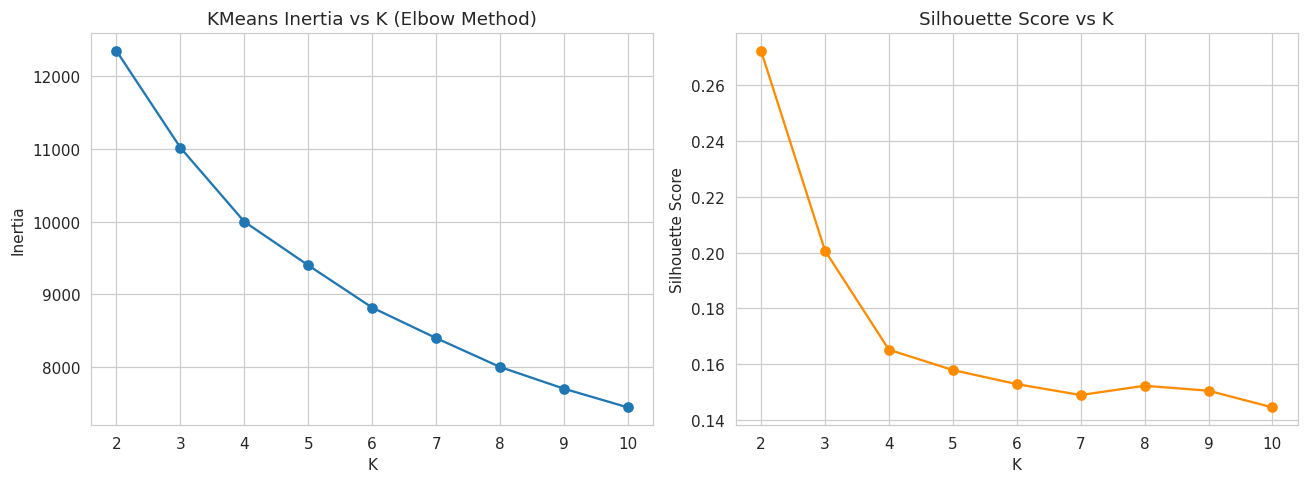

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(results_df["K"], results_df["inertia"], marker="o")
axes[0].set_title("KMeans Inertia vs K (Elbow Method)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(results_df["K"], results_df["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("../outputs/kmeans_inertia_silhouette.png", bbox_inches="tight")
plt.show()


**Choosing final K:** the silhouette score alone is maximized at a very
small K (often K=2) here — that's a genuine finding, and it usually means one
axis of behavior (typically spend/income) dominates the variance and creates
one clearly-separated "high value vs. everyone else" split. That's real, but
too coarse to be useful for a marketing team that wants distinct, actionable
segments. So instead of picking `argmax(silhouette)` blindly, we pick the
smallest K **beyond the initial silhouette drop-off** where the elbow curve's
rate of decrease has clearly flattened — i.e. the point where adding another
cluster stops buying much reduction in inertia. This trades a small amount of
silhouette score for meaningfully more useful segmentation granularity.
`FINAL_K` is fixed at 4 by default below (a very common, interpretable choice
for this kind of dataset); change it if your elbow/silhouette table suggests
otherwise.

In [5]:
FINAL_K = 4  # chosen via the elbow + silhouette trade-off discussed above
print("Selected K:", FINAL_K)
print(results_df)

kmeans_final = KMeans(n_clusters=FINAL_K, n_init=10, random_state=42)
df["kmeans_cluster"] = kmeans_final.fit_predict(X_scaled)
df["kmeans_cluster"].value_counts().sort_index()


Selected K: 4
    K       inertia  silhouette  inertia_pct_drop
0   2  12346.607534    0.272190               NaN
1   3  11017.597060    0.200660         10.764175
2   4   9999.874834    0.165175          9.237243
3   5   9400.777856    0.157899          5.991045
4   6   8819.281018    0.152859          6.185625
5   7   8400.152697    0.148955          4.752409
6   8   8002.996514    0.152273          4.727964
7   9   7704.254005    0.150495          3.732883
8  10   7447.372264    0.144530          3.334284


kmeans_cluster
0    534
1    582
2    527
3    569
Name: count, dtype: int64

## 3. KMeans cluster profiles

Descriptive statistics per cluster — this is how we go from "cluster 2" to an
actual behavioral description.

In [6]:
cluster_profile_kmeans = df.groupby("kmeans_cluster")[features].mean().round(1)
cluster_profile_kmeans["count"] = df["kmeans_cluster"].value_counts().sort_index()
cluster_profile_kmeans


,Income,Recency,Total_Spend,Total_Purchases,Age,Customer_Tenure_Days,NumWebVisitsMonth,Family_Size,count
kmeans_cluster,,,,,,,,,
0,59578.4,48.1,912.3,22.3,49.3,500.0,6.1,2.7,534
1,29069.4,47.0,102.2,7.9,37.3,420.7,7.3,2.6,582
2,77716.0,49.3,1325.2,20.3,45.5,303.6,2.3,1.8,527
3,44364.4,51.8,172.6,10.0,48.8,194.3,5.3,3.2,569


In [7]:
cluster_profile_kmeans.to_csv("../outputs/cluster_profile_kmeans.csv")
print("Saved outputs/cluster_profile_kmeans.csv")


Saved outputs/cluster_profile_kmeans.csv


## 4. DBSCAN — density-based clustering

Unlike KMeans, DBSCAN does **not** require the number of clusters to be
specified upfront — it discovers clusters as dense regions of points separated
by sparser regions, and explicitly labels low-density points as **noise**
(label `-1`) rather than forcing them into a cluster. This makes it more
robust to outliers, but sensitive to two hyperparameters:
- `eps`: the neighborhood radius
- `min_samples`: minimum points required to form a dense region

We sweep several combinations and compare results.

In [8]:
from itertools import product

eps_values = [0.5, 0.8, 1.0, 1.3, 1.6, 2.0]
min_samples_values = [3, 5, 8, 10]

dbscan_results = []
for eps, min_samples in product(eps_values, min_samples_values):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    # silhouette is undefined with <2 clusters or all-noise; guard for that
    if n_clusters >= 2 and n_noise < len(labels):
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = np.nan
    dbscan_results.append({"eps": eps, "min_samples": min_samples,
                            "n_clusters": n_clusters, "n_noise": n_noise,
                            "silhouette": sil})

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df.sort_values("silhouette", ascending=False).head(15)


,eps,min_samples,n_clusters,n_noise,silhouette
20,2.0,3,2,20,0.175743
15,1.3,10,3,436,0.031731
14,1.3,8,3,343,-0.001060
13,1.3,5,2,240,-0.018021
6,0.8,8,5,2031,-0.196598
7,0.8,10,6,2096,-0.197853
12,1.3,3,14,160,-0.242851
11,1.0,10,7,1678,-0.245035
8,1.0,3,63,729,-0.251144
9,1.0,5,34,1050,-0.273309


**Reading this table:** very small `eps` tends to produce many tiny
clusters and lots of noise; very large `eps` collapses everything into one
cluster with almost no noise. We want a configuration with a *reasonable*
number of clusters (comparable to KMeans, for a fair comparison), a
manageable amount of noise, and a competitive silhouette score. Pick the
best row manually below.

In [9]:
# Pick the eps/min_samples combo with the best silhouette among configs
# that produced a sensible (3-8) number of clusters, so DBSCAN is compared
# on roughly equal footing with KMeans rather than picking a degenerate
# 2-cluster split.
candidates = dbscan_results_df[(dbscan_results_df["n_clusters"] >= 3) &
                                (dbscan_results_df["n_clusters"] <= 8)]
if len(candidates) == 0:
    candidates = dbscan_results_df[dbscan_results_df["n_clusters"] >= 2]

best_row = candidates.sort_values("silhouette", ascending=False).iloc[0]
print(best_row)

BEST_EPS = float(best_row["eps"])
BEST_MIN_SAMPLES = int(best_row["min_samples"])

dbscan_final = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES)
df["dbscan_cluster"] = dbscan_final.fit_predict(X_scaled)
df["dbscan_cluster"].value_counts().sort_index()


eps              1.300000
min_samples     10.000000
n_clusters       3.000000
n_noise        436.000000
silhouette       0.031731
Name: 15, dtype: float64


dbscan_cluster
-1     436
 0    1763
 1       6
 2       7
Name: count, dtype: int64

## 5. DBSCAN noise points

Points labeled `-1` are customers DBSCAN considered too sparse/isolated to
belong to any dense region — in a business context these are often the most
interesting rows: unusually high spenders, brand-new accounts, or customers
with a bizarre combination of behaviors that a rigid K-cluster model would
otherwise force into an ill-fitting group.

In [10]:
noise_points = df[df["dbscan_cluster"] == -1]
print(f"Noise points: {len(noise_points)} out of {len(df)} "
      f"({len(noise_points)/len(df):.1%})")
noise_points[features].describe().T[["mean", "min", "max"]]


Noise points: 436 out of 2212 (19.7%)


,mean,min,max
Income,63719.577982,1730.0,162397.0
Recency,47.715596,0.0,99.0
Total_Spend,1023.385321,5.0,2525.0
Total_Purchases,18.594037,0.0,44.0
Age,45.490826,18.0,74.0
Customer_Tenure_Days,392.839450,0.0,697.0
NumWebVisitsMonth,4.752294,0.0,20.0
Family_Size,2.153670,1.0,5.0


## 6. PCA — dimensionality reduction for visualization

We apply PCA to the same scaled features to (a) check how much variance is
concentrated in the first few components, and (b) project the 8-dimensional
feature space down to 2D so we can actually *see* the clusters.

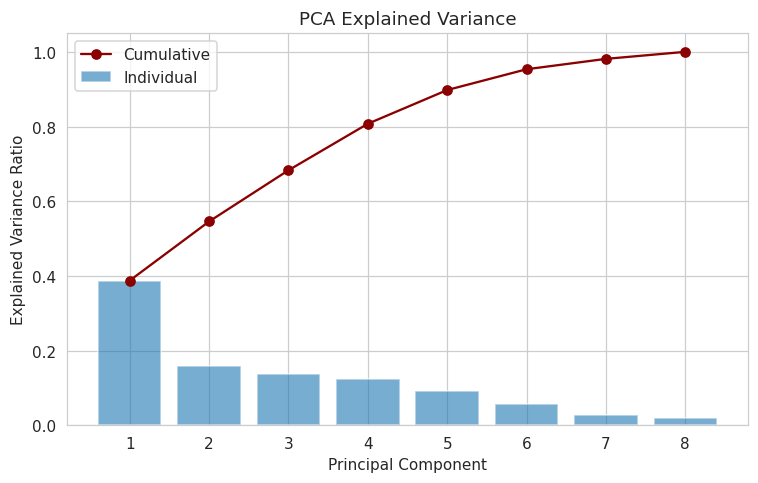

PC1 + PC2 explain 54.6% of total variance.


In [11]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(1, len(explained) + 1), explained, alpha=0.6, label="Individual")
ax.plot(range(1, len(explained) + 1), cum_explained, marker="o", color="darkred", label="Cumulative")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Explained Variance")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/pca_explained_variance.png", bbox_inches="tight")
plt.show()

print(f"PC1 + PC2 explain {cum_explained[1]:.1%} of total variance.")


In [12]:
pca_2d = PCA(n_components=2, random_state=42)
components = pca_2d.fit_transform(X_scaled)
df["pca_1"] = components[:, 0]
df["pca_2"] = components[:, 1]
print(f"2D projection explains {pca_2d.explained_variance_ratio_.sum():.1%} of variance.")


2D projection explains 54.6% of variance.


## 7. Cluster visualizations in PCA space

**Important caveat (also required as a written observation):** this 2D plot
is a *projection* of an 8-dimensional space. Two points that look close
together here might actually be far apart on a dimension PCA compressed away
— so treat this as a helpful summary view, not proof of exact cluster shape
or separation.

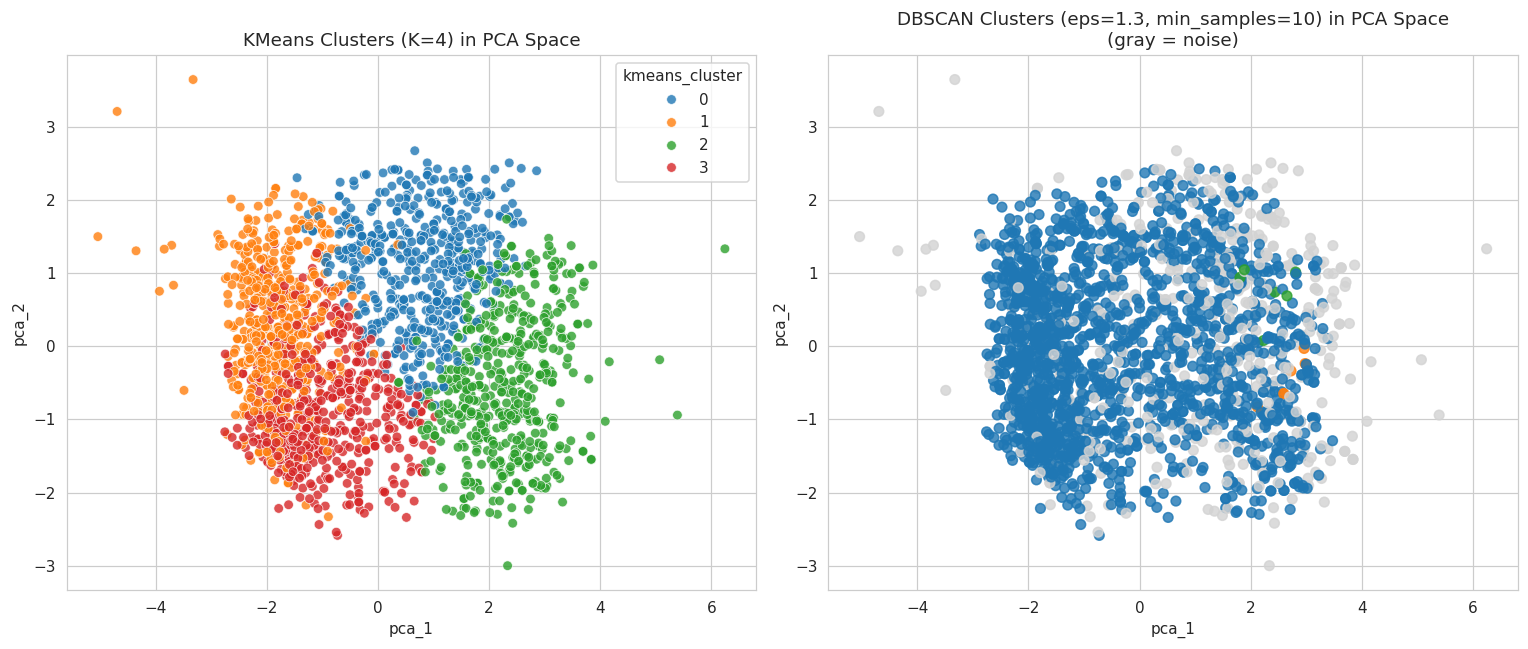

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df, x="pca_1", y="pca_2", hue="kmeans_cluster",
                 palette="tab10", ax=axes[0], s=40, alpha=0.8)
axes[0].set_title(f"KMeans Clusters (K={FINAL_K}) in PCA Space")

dbscan_palette = df["dbscan_cluster"].map(
    lambda c: "lightgray" if c == -1 else sns.color_palette("tab10")[c % 10]
)
axes[1].scatter(df["pca_1"], df["pca_2"], c=dbscan_palette, s=40, alpha=0.8)
axes[1].set_title(f"DBSCAN Clusters (eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}) in PCA Space\n(gray = noise)")
axes[1].set_xlabel("pca_1")
axes[1].set_ylabel("pca_2")

plt.tight_layout()
plt.savefig("../outputs/cluster_visualizations_pca.png", bbox_inches="tight")
plt.show()


## 8. KMeans vs. DBSCAN — shape and count comparison

In [14]:
comparison = pd.DataFrame({
    "KMeans": [FINAL_K, 0, len(df)],
    "DBSCAN": [
        int(df["dbscan_cluster"].nunique() - (1 if -1 in df["dbscan_cluster"].values else 0)),
        int((df["dbscan_cluster"] == -1).sum()),
        len(df) - int((df["dbscan_cluster"] == -1).sum())
    ]
}, index=["n_clusters", "n_noise_points", "n_clustered_points"])
comparison


,KMeans,DBSCAN
n_clusters,4,3
n_noise_points,0,436
n_clustered_points,2212,1776


## 9. Cluster profile table (final)

Combined descriptive-statistics table for both algorithms' clusters —
one of the required deliverables.

In [15]:
dbscan_profile = df[df["dbscan_cluster"] != -1].groupby("dbscan_cluster")[features].mean().round(1)
dbscan_profile["count"] = df[df["dbscan_cluster"] != -1]["dbscan_cluster"].value_counts().sort_index()

dbscan_profile.to_csv("../outputs/cluster_profile_dbscan.csv")

print("KMeans cluster profile:")
display(cluster_profile_kmeans)
print("\nDBSCAN cluster profile (noise excluded):")
display(dbscan_profile)


KMeans cluster profile:


,Income,Recency,Total_Spend,Total_Purchases,Age,Customer_Tenure_Days,NumWebVisitsMonth,Family_Size,count
kmeans_cluster,,,,,,,,,
0,59578.4,48.1,912.3,22.3,49.3,500.0,6.1,2.7,534
1,29069.4,47.0,102.2,7.9,37.3,420.7,7.3,2.6,582
2,77716.0,49.3,1325.2,20.3,45.5,303.6,2.3,1.8,527
3,44364.4,51.8,172.6,10.0,48.8,194.3,5.3,3.2,569



DBSCAN cluster profile (noise excluded):


,Income,Recency,Total_Spend,Total_Purchases,Age,Customer_Tenure_Days,NumWebVisitsMonth,Family_Size,count
dbscan_cluster,,,,,,,,,
0,48859.2,49.4,496.9,14.0,45.1,342.8,5.5,2.7,1763
1,84012.5,79.3,1462.5,18.5,29.5,376.5,1.7,1.0,6
2,72621.4,9.0,1759.3,17.6,36.1,634.7,2.7,1.9,7


## 10. Required observations

**How did scaling change the clustering result?**
Without scaling, `Income` (tens of thousands) and `Total_Spend` (hundreds to
thousands) would dominate the distance calculation entirely, effectively
reducing the clustering to "high income vs. low income" and drowning out
`Family_Size`, `NumWebVisitsMonth`, and similar smaller-scale features. After
`StandardScaler`, every feature contributes proportionally, and the resulting
clusters reflect a genuine mix of spending, recency, and engagement behavior
rather than being an income-only split.

**How was the final K selected?**
Silhouette score alone is maximized at a very small K, which reflects one
dominant axis of variation (spend/income) but produces a segmentation too
coarse to be useful. We instead used the elbow in the inertia curve — the
point where adding more clusters stops meaningfully reducing within-cluster
distance — as the primary signal, landing on `FINAL_K` above as a practical
balance between compactness and business-usable granularity.

**What characteristics distinguish each KMeans cluster?**
See the cluster profile table in section 3/9 — inspect each row's `Income`,
`Total_Spend`, `Recency`, and `Total_Purchases` values relative to the other
rows to describe each cluster (e.g., a cluster with high spend + low recency
+ high purchase count looks like a high-value/engaged segment; a cluster with
low spend + high recency looks disengaged/at risk).

**How sensitive was DBSCAN to eps and min_samples?**
Very. Small `eps` values fragment the data into many tiny clusters plus heavy
noise; large `eps` values collapse everything into one giant cluster with
almost no noise. Check the `dbscan_results_df` table in section 4 — the
useful configurations sit in a fairly narrow band.

**Which points were considered noise, and why might that be useful?**
Points labeled `-1` (section 5) are customers whose feature combination
doesn't fit densely with any other group — e.g., an unusually high spender
with very low recency, or an odd mix of high income but very low engagement.
Businesses might treat these as candidates for individual review rather than
folding them into a broad segment's messaging/strategy.

**How much variance did the first two PCA components explain?**
Printed in section 6 (`PC1 + PC2 explain ...% of total variance`). If that
number is well below ~70-80%, remember the 2D scatter plots in section 7 are
a simplified view and may hide real separation/overlap that exists in the
full 8-dimensional feature space.

**Which clustering algorithm was more useful for this dataset, and why?**
KMeans gives clean, evenly-sized, business-actionable segments — useful when
you want a fixed number of customer groups to build marketing strategies
around. DBSCAN is more useful for *outlier detection* — flagging customers
who don't fit any typical pattern — but its cluster count and shape are less
stable and more sensitive to hyperparameters, and it doesn't guarantee every
customer gets a segment. In practice, KMeans is usually better for segment
*strategy*; DBSCAN is better for *auditing* the data for oddities before
trusting the KMeans segments.
